In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math
import random

In [2]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('using:',blurtool.device)
device=blurtool.device
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))

using: cuda:0
True
1
0
NVIDIA GeForce GTX 1080


# Nonstationary blur modeling using robust eigenkernels

Abstract: In this paper we propose a robust low rank model for restoring images corrupted by a nonstationary blur. This work improves the eigenkernels model proposed by Gwak and Yang. Their method uses standard Principal Component Analysis (PCA), and is thus not well suited to data with outliers. We replace PCA by its robust version. Numerical experiments show that our proposal offers reliable blur description and restoration even in the presence of salt-and-pepper noise, in which the original framework fails.

### Example 0
figure showing LSV convolution, approximate LSV filter and PCA eigenkernel forward method.

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)
sampled_shape= (8, 8)
finished row  0
finished row  1
finished row  2
finished row  3
finished row  4
finished row  5
finished row  6
finished row  7
finished row  8
finished row  9
finished row  10
finished row  11
finished row  12
finished row  13
finished row  14
finished row  15
finished row  16
finished row  17
finished row  18
finished row  19
finished row  20
finished row  21
finished row  22
finished row  23
finished row  24
finished row  25
finished row  26
finished row  27
finished row  28
finished row  29
finished row  30
finished row  31
finished row  32
finished row  33
finished row  34
finished row  35
finished row  36
finished row  37
finished row  38
finished row  39
finished row  40
finished row  41
finished row  42
finished row  43
finished row  44
finished row  45
finished row  46
finished row  47
finished row  48
finished row  49
finished row  50
finished row  51
finished row  52
finished row  53
finished row 

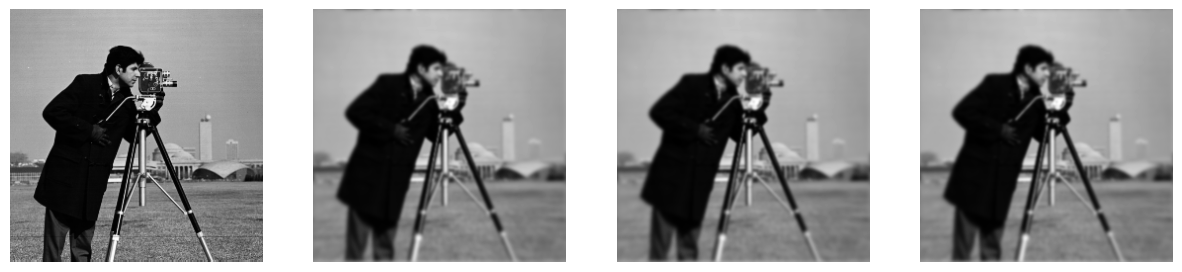

-------------------------------------------------------
forward_timer_lsvc= 43.11622202442959
forward_timer_pca= 0.038953982293605804
-------------------------------------------------------
PSNR(blurred_lsvc,blurred_pca)= tensor(52.3047, device='cuda:0', dtype=torch.float64)
-------------------------------------------------------
SSIM(blurred_lsvc,blurred_pca)= tensor(0.9999, dtype=torch.float64)


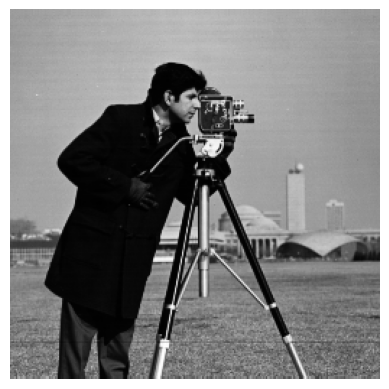

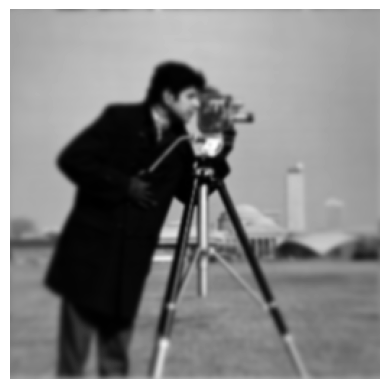

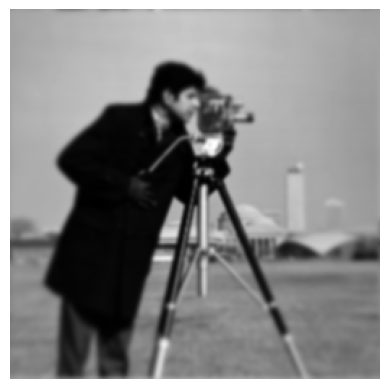

In [7]:
# test approx=False in nonstationary blur with a nondecomposed lattice (parallel forward)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze().to(device)
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.122,'by':0.1,'gamma_x':1,'gamma_y':1} # simpler exp0
# lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1} # 0.07
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)
print('sampled_shape=',sampled_shape)
r=15
pars_pca={'r':r}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

# computes linear space-variant convolution using invariant convolutions
rgblur_lsvc=blurtool.NonstationaryBlur(lat)
blurred_test_image_lsvc=rgblur_lsvc.forward(test_image,n_pool=8,debug=True)
print('computed lsvc blurred image')

# pca lat blur 
pca_blur=blurtool.NonstationaryBlur(pca_lat)
blurred_test_image_pca=pca_blur.forward(test_image)
print('computed pca lat blurred image')

# # results
fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_lsvc.cpu(),cmap='gray')
ax[2].axis('off')
ax[2].imshow(blurred_test_image.cpu(),cmap='gray')
ax[3].axis('off')
ax[3].imshow(blurred_test_image_pca.cpu(),cmap='gray')
plt.show()

print('-------------------------------------------------------')
print('forward_timer_lsvc=',rgblur_lsvc.forward_timer)
print('forward_timer_pca=',pca_blur.forward_timer)
print('-------------------------------------------------------')
print('PSNR(blurred_lsvc,blurred_pca)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image_pca))
print('-------------------------------------------------------')
print('SSIM(blurred_lsvc,blurred_pca)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image_pca))

# save images
plt.imshow(test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/ex0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_lsvc.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/ex0_y_lvsc.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_pca.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/ex0_y_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

## Numerical experiments

### Example 1 (salt and pepper corrupted PSF)

In [9]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# set seed for reproducibility
# torch.manual_seed(0)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
# test_image=Image.open('../../data/ccia/47.gif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze().double()

# resize and normalize
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
test_image=test_image.to(device)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.05,'ay':0.05,'bx':0.122,'by':0.1,'gamma_x':1,'gamma_y':1} # simpler exp0

lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# # find out the greatest salt and lowest pepper values
# salt_val=-10000
# pepper_val=10000
# for key in sampled_lat.kernels:
#     if torch.max(sampled_lat.kernels[key].psf_data)>salt_val:
#         salt_val=torch.max(sampled_lat.kernels[key].psf_data)
#     if torch.min(sampled_lat.kernels[key].psf_data)<pepper_val:
#         pepper_val=torch.min(sampled_lat.kernels[key].psf_data)

# use individual salt and pepper values
salt_val=None
pepper_val=None

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.03,salt_val=salt_val,pepper_val=pepper_val) # 0.1 # 0.2
     # amount was 0.1

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)


In [10]:
# # find amplitude of maximum values
# wlamb_unraveled=torch.zeros(sampled_shape)
# max_sampled_kernels_unraveled=[]
# for key in sampled_lat.kernels:
#     #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
#     max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

# amplitude_lamb=max(max_sampled_kernels_unraveled)
# print(amplitude_lamb)

# # sampled_shape=(8,8)
# # psf_pars={'sx':0.8,'sy':0.8}
# # wlamb_unraveled=blurtool.Kernel(sampled_shape,mode='gaussian',psf_pars=psf_pars)()
# # wlamb_unraveled=wlamb_unraveled-torch.min(wlamb_unraveled)
# # # wlamb_unraveled=0.03+2.8*wlamb_unraveled
# # wlamb_unraveled=0.015+4.5*wlamb_unraveled 
# # wlamb_unraveled=torch.round(wlamb_unraveled,decimals=3)

# # find amplitude of maximum values
# wlamb_unraveled=torch.zeros(sampled_shape)
# max_sampled_kernels_unraveled=[]
# for key in sampled_lat.kernels:
#     #print(torch.round(torch.max(sampled_lat.kernels[key].psf_data),decimals=3).item())
#     max_sampled_kernels_unraveled.append(torch.max(sampled_lat.kernels[key].psf_data).item())

# amplitude_lamb=max(max_sampled_kernels_unraveled)

# for key in sampled_lat.kernels:
# #     wlamb_unraveled[key[0],key[1]]=torch.max(sampled_lat.kernels[key].psf_data)+(0.13-amplitude_lamb)
# #     wlamb_unraveled[key[0],key[1]]=torch.round(wlamb_unraveled[key[0],key[1]],decimals=3)
#     wlamb_unraveled[key[0],key[1]]=0.035+0.06*torch.max(sampled_lat.kernels[key].psf_data)/amplitude_lamb
#     wlamb_unraveled[key[0],key[1]]=torch.round(wlamb_unraveled[key[0],key[1]],decimals=3)
    

# # visualize wlamb_unraveled
# fig, ax = plt.subplots()
# ax.imshow(wlamb_unraveled,cmap='gray')
# for i in range(sampled_shape[0]):
#     for j in range(sampled_shape[1]):
#         ax.text(j, i, str(wlamb_unraveled.clone().detach().numpy()[i, j]), color='r', ha='center', va='center')

        
# # write raveled wlamb
# wlamb=[None for i in range(sampled_shape[0]*sampled_shape[1])]
# for i in range(sampled_shape[0]):
#     for j in range(sampled_shape[1]):
#         raveled_pos=blurtool.ravel_multi_index((i,j),sampled_shape)
#         wlamb[raveled_pos]=wlamb_unraveled[i,j].item()
        
# print(wlamb)
        

mu= tensor(137.2751) . lamb= tensor([0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490, 0.1490,
        0.1490], dtype=torch.float64) . rank= 0


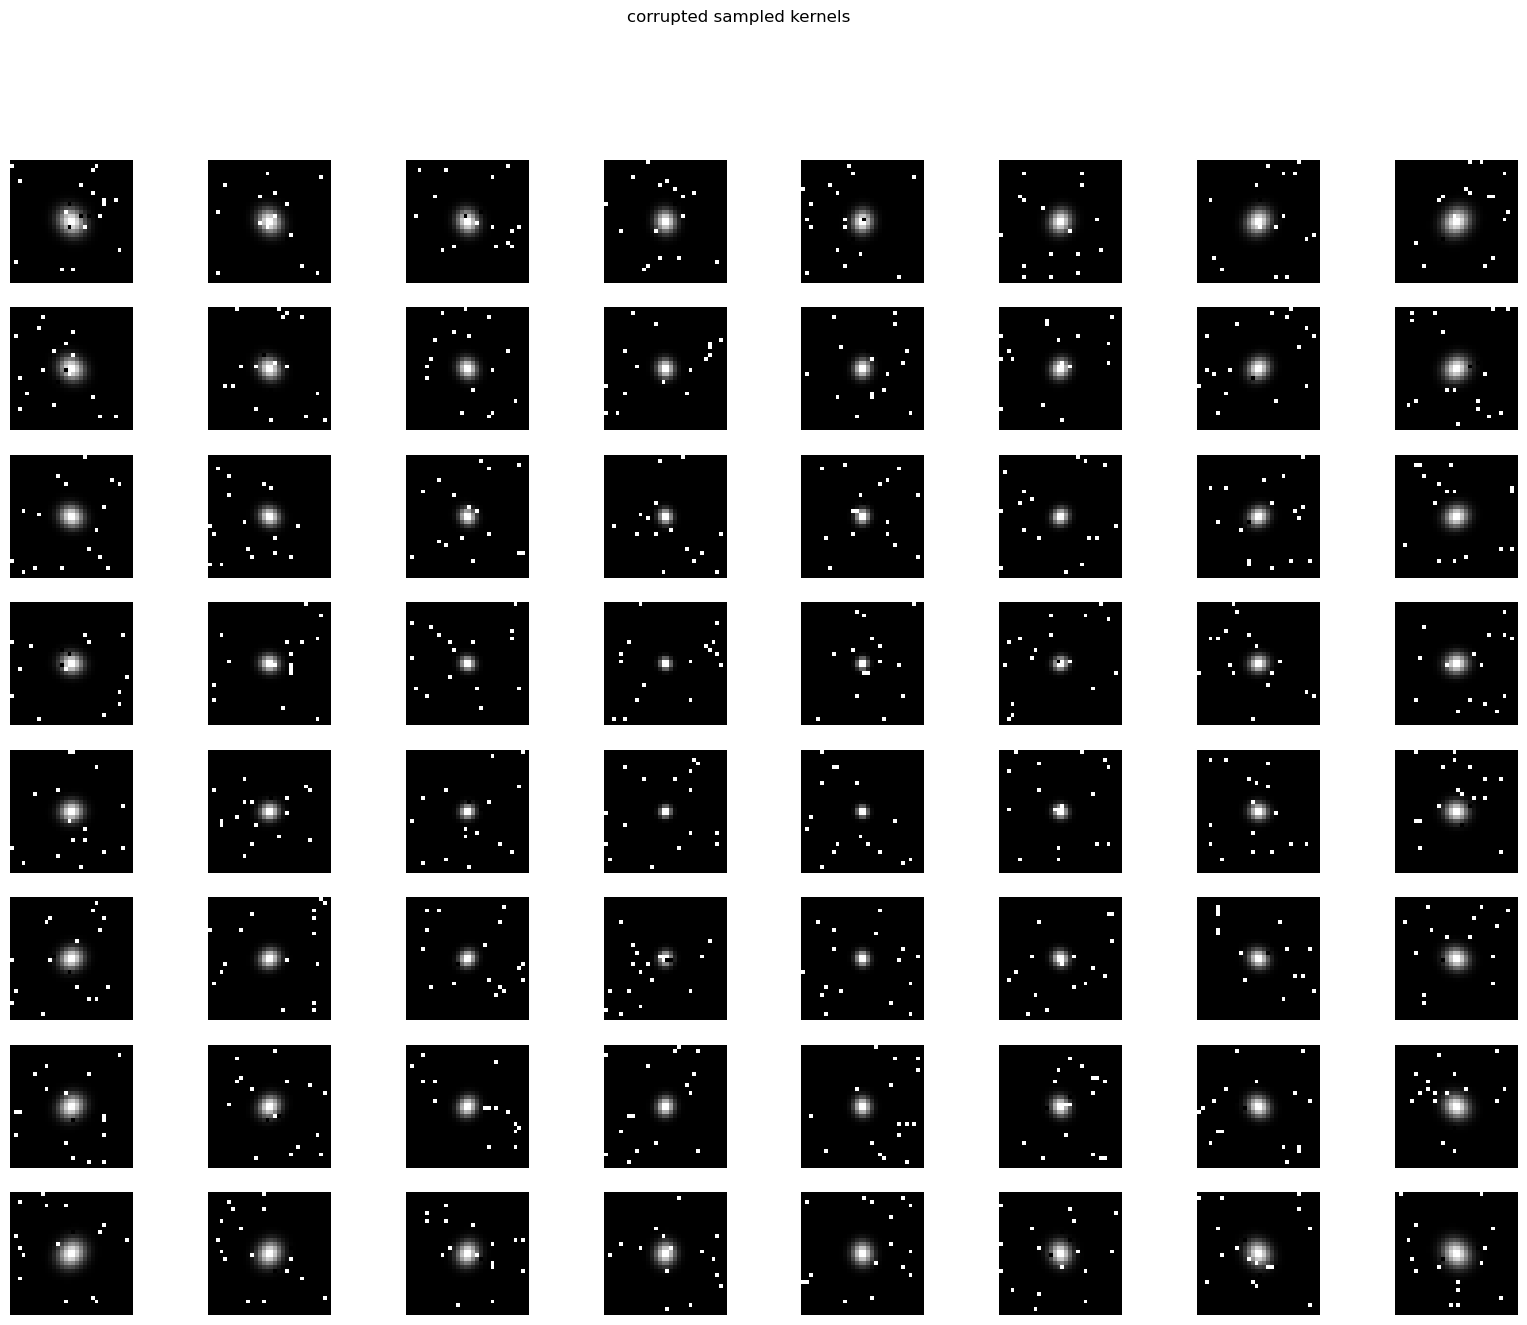

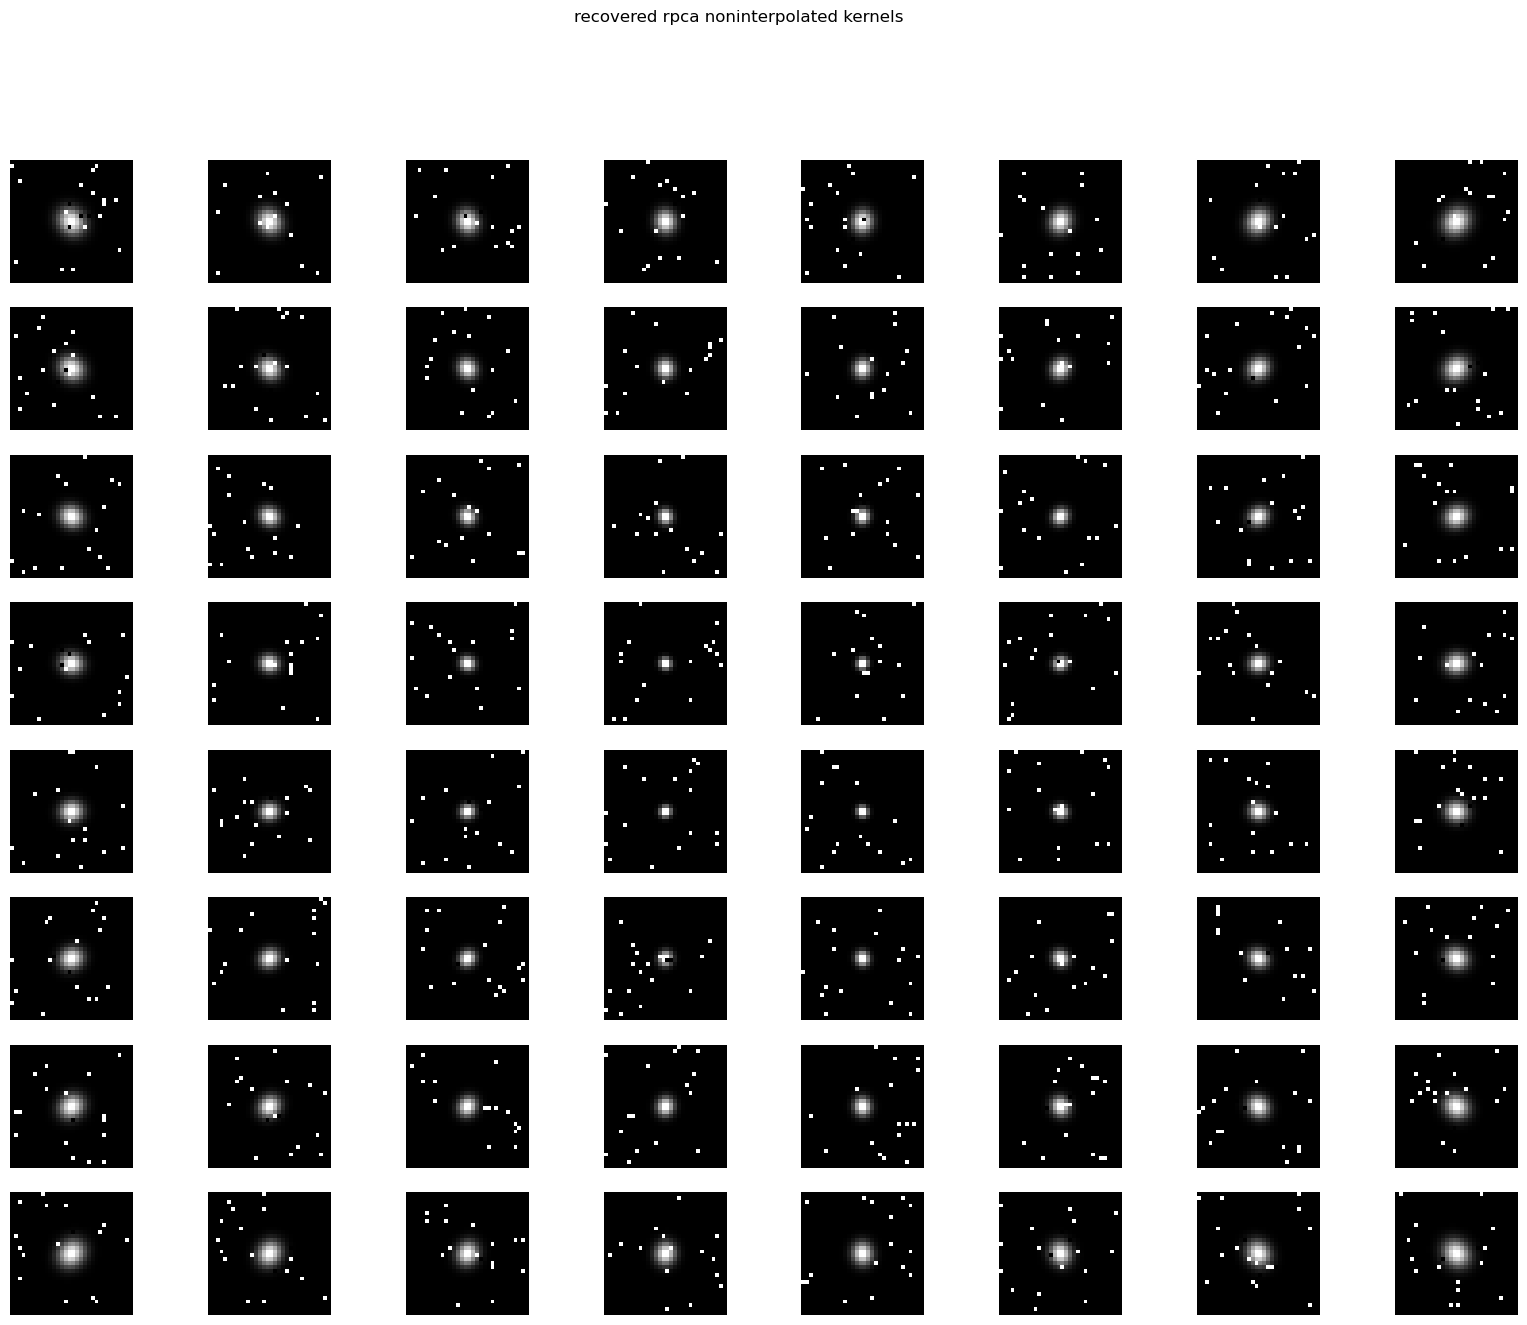

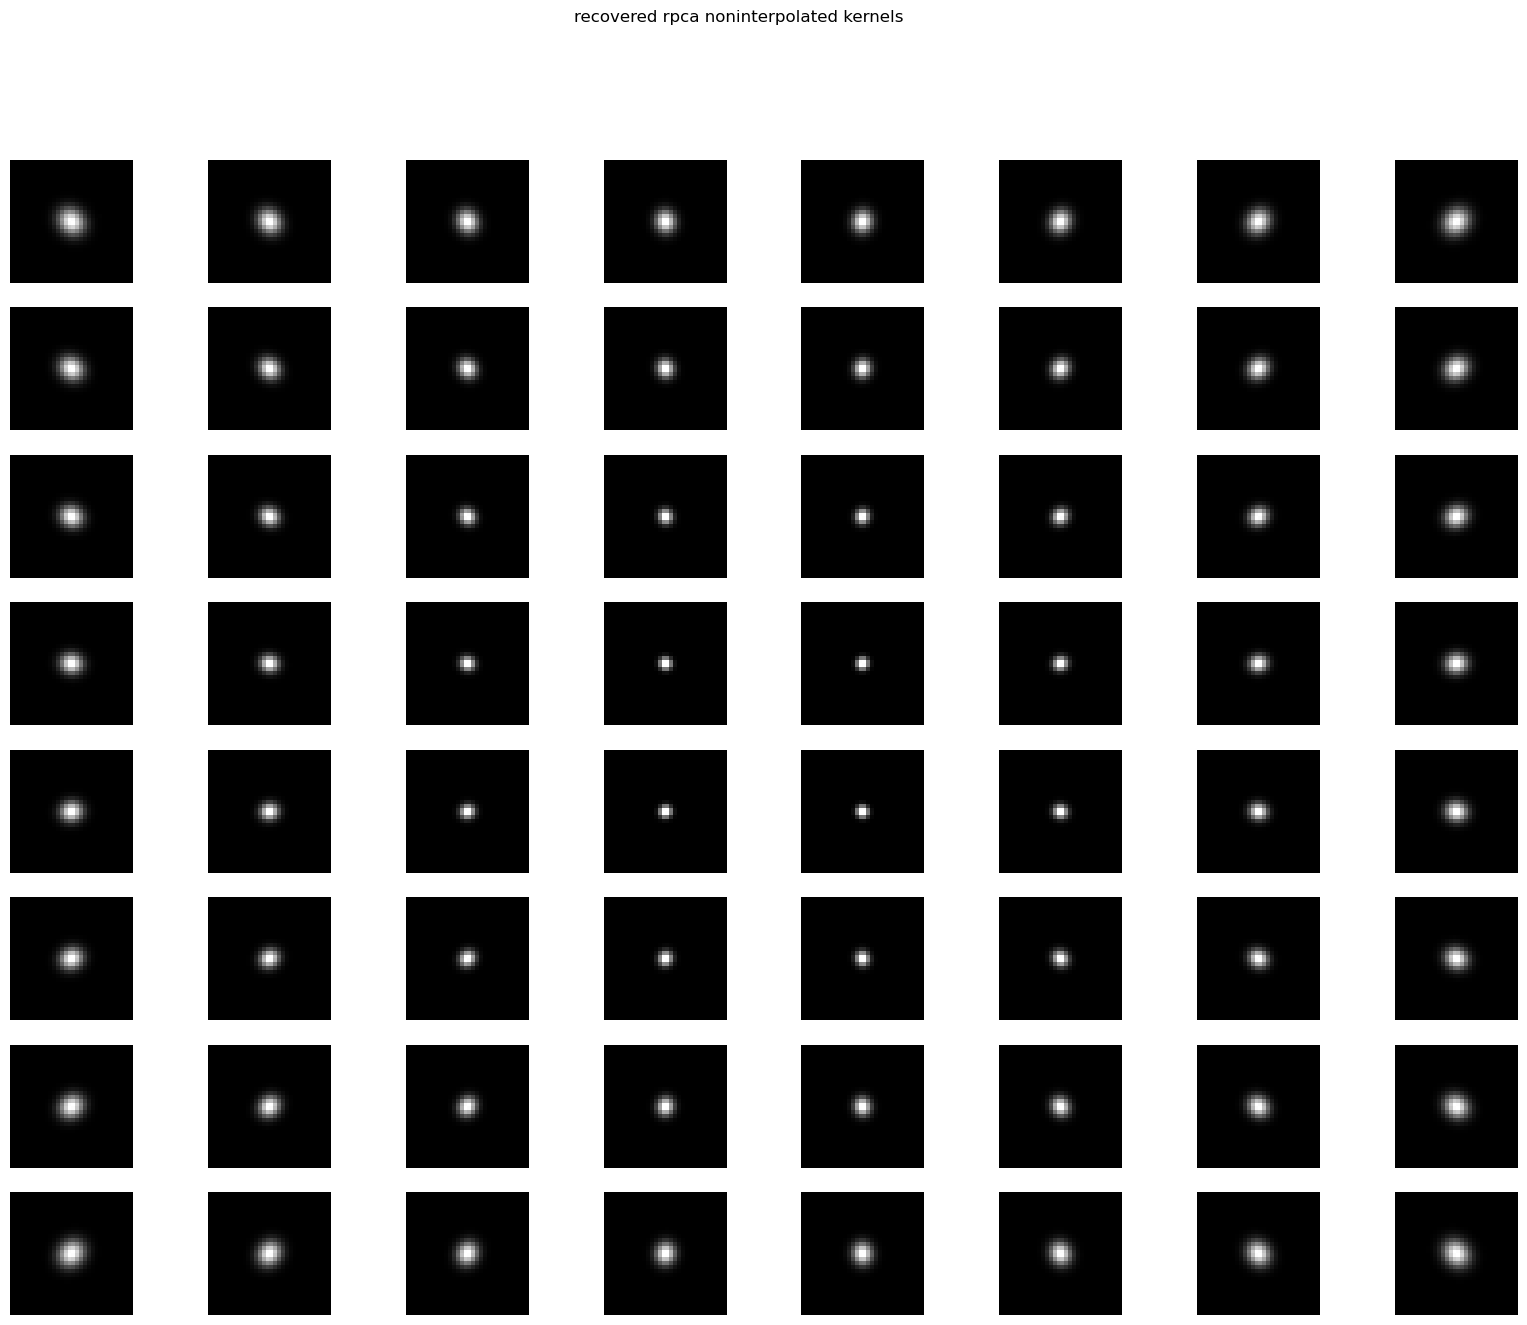

In [11]:
# decompose sampled lattice
r=64
pars_pca={'r':r}
pars_rpca={'lamb':0.149,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # 0.08!!! or .09 for 0.1 of amount

pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)

# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])().cpu(),cmap='gray')
plt.show()

# plot reconsctructed pca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
plt.show()

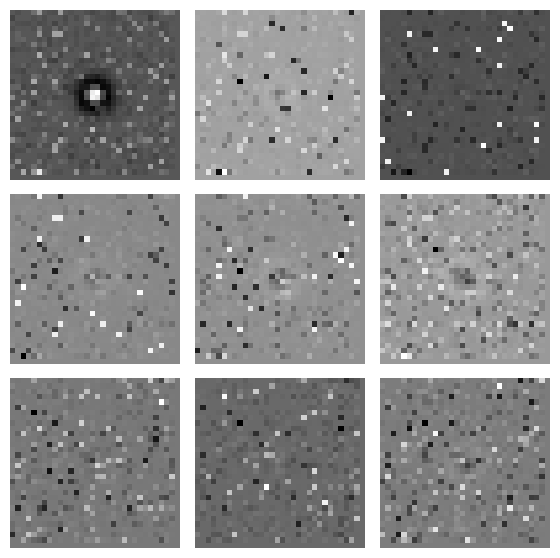

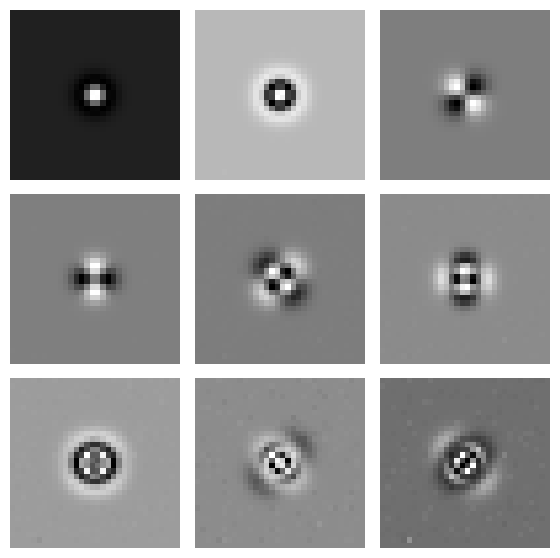

In [12]:
# plot pca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
plt.savefig('fig/res0_pca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plot rpca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
plt.savefig('fig/res0_rpca_9eigenkernels.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

### scree plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


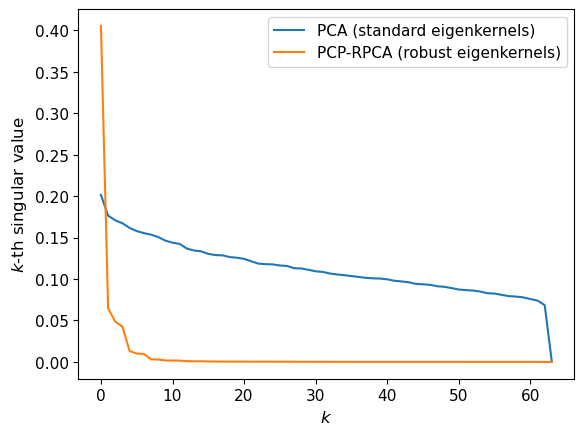

In [13]:
plt.plot(pca_lat.singularvalues[1:],label='PCA (standard eigenkernels)')
plt.plot(rpca_lat.singularvalues[1:],label=r'PCP-RPCA (robust eigenkernels)')
plt.ylabel(r'$k$-th singular value',fontsize=12)
plt.xlabel(r'$k$',fontsize=12)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('fig/res0_singular_values.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [14]:
# suggested lambda value 
1/math.sqrt(kernel_shape[0]*kernel_shape[1])

0.03125

In [15]:
# mean PSNR and SSIM

psnr_pca=[]
psnr_rpca=[]
psnr_wrpca=[]
ssim_pca=[]
ssim_rpca=[]
ssim_wrpca=[]

resampled_lat=lat.sample(sampled_shape)
lat_pca_gt=blurtool.DecomposeLattice(resampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

for key in sampled_lat.kernels:
#     psnr_pca.append(blurtool.psnr(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
#     psnr_rpca.append(blurtool.psnr(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())    
#     ssim_pca.append(blurtool.ssim(resampled_lat.kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
#     ssim_rpca.append(blurtool.ssim(resampled_lat.kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())
    psnr_pca.append(blurtool.psnr(lat_pca_gt.noninterpolated_kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    psnr_rpca.append(blurtool.psnr(lat_pca_gt.noninterpolated_kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())    
    ssim_pca.append(blurtool.ssim(lat_pca_gt.noninterpolated_kernel(key)(),pca_lat.noninterpolated_kernel(key)()).item())
    ssim_rpca.append(blurtool.ssim(lat_pca_gt.noninterpolated_kernel(key)(),rpca_lat.noninterpolated_kernel(key)()).item())

print('-----------------------------')
print('mean PSNR(psf,psf_pca)=',sum(psnr_pca)/len(psnr_pca))
print('mean SSIM(psf,psf_pca)=',sum(ssim_pca)/len(ssim_pca))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca)=',sum(psnr_rpca)/len(psnr_rpca))
print('mean SSIM(psf,psf_rpca)=',sum(ssim_rpca)/len(ssim_rpca))
print('-----------------------------')

-----------------------------
mean PSNR(psf,psf_pca)= 18.256187945604324
mean SSIM(psf,psf_pca)= 0.9886097743495549
-----------------------------
mean PSNR(psf,psf_rpca)= 79.9382631778717
mean SSIM(psf,psf_rpca)= 0.9999791495777537
-----------------------------


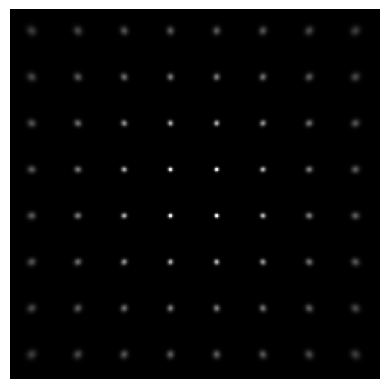

In [16]:
plt.imshow(lat.grid((8,8),blur=True,normalize=False).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

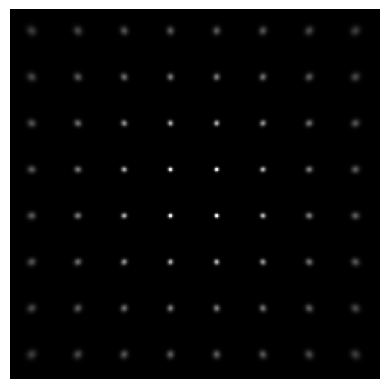

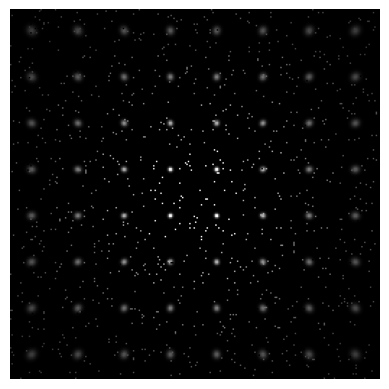

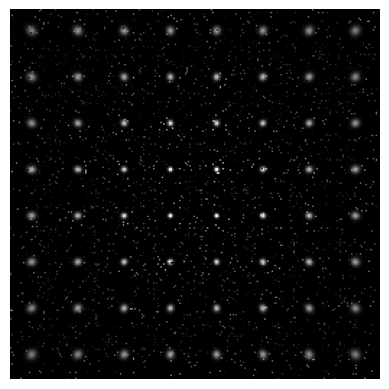

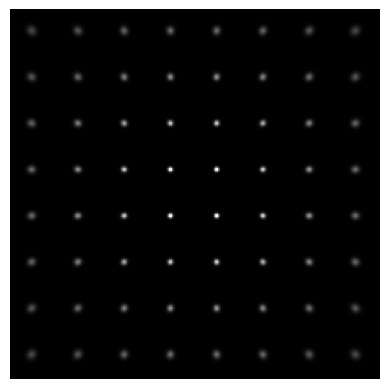

In [17]:
normalize=False

plt.imshow(lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

resampled_lat=sampled_lat.sample(sampled_shape,normalize=normalize,normalize_mode='minmax')
view_sampled_lat=blurtool.InterpolateLattice(resampled_lat,img_shape,mode='zero_dummy')
plt.imshow(view_sampled_lat.grid(sampled_shape,blur=True).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_hplusnoise.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_hhat_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=normalize).cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_hhat_rpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [30]:
# sample original lattice
resampled_lat_gt=lat.sample(sampled_shape)


r=64
pars_gt_pca={'r':r}
lat_gt=blurtool.DecomposeLattice(resampled_lat_gt,img_shape,mode='pca',decompose_pars=pars_pca)
blur_gt=blurtool.NonstationaryBlur(lat_gt)

blurred_test_image_gt=blur_gt.forward(test_image)

finished row  0
finished row  1
finished row  2
finished row  3
finished row  4
finished row  5
finished row  6
finished row  7
finished row  8
finished row  9
finished row  10
finished row  11
finished row  12
finished row  13
finished row  14
finished row  15
finished row  16
finished row  17
finished row  18
finished row  19
finished row  20
finished row  21
finished row  22
finished row  23
finished row  24
finished row  25
finished row  26
finished row  27
finished row  28
finished row  29
finished row  30
finished row  31
finished row  32
finished row  33
finished row  34
finished row  35
finished row  36
finished row  37
finished row  38
finished row  39
finished row  40
finished row  41
finished row  42
finished row  43
finished row  44
finished row  45
finished row  46
finished row  47
finished row  48
finished row  49
finished row  50
finished row  51
finished row  52
finished row  53
finished row  54
finished row  55
finished row  56
finished row  57
finished row  58
finishe

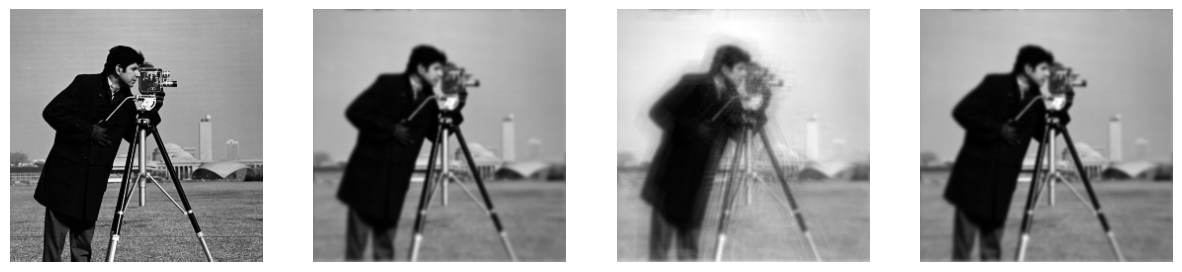

blur.forward_timer= 43.27208920009434
pca_blur.forward_timer= 0.1585975820198655
rpca_blur.forward_timer= 0.1607309370301664
PSNR(blurred,pca_blurred)= tensor(16.2086, device='cuda:0', dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(56.4314, device='cuda:0', dtype=torch.float64)
SSIM(blurred,pca_blurred)= tensor(0.8982, dtype=torch.float64)
SSIM(blurred,rpca_blurred)= tensor(0.9999, dtype=torch.float64)


In [31]:
## blur a test image 

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)

blurred_test_image=blur.forward(test_image,n_pool=8,debug=True)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image.cpu(),cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image.cpu(),cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image.cpu(),cmap='gray')

plt.show()

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image_gt,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image_gt,rpca_blurred_test_image))

print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image_gt,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image_gt,rpca_blurred_test_image))


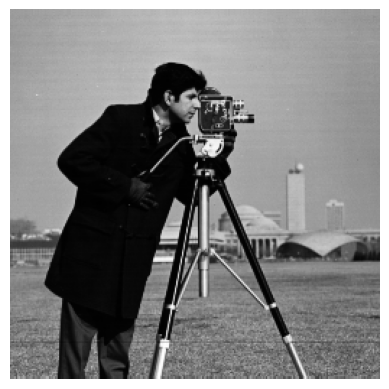

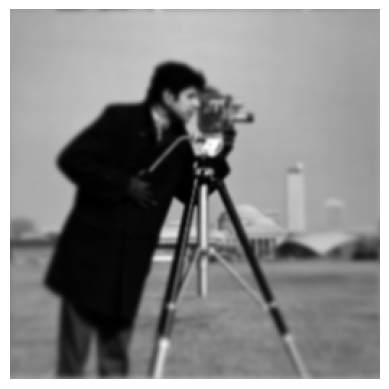

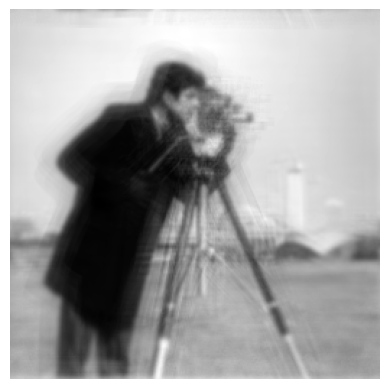

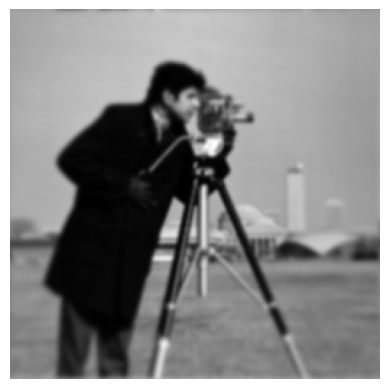

In [32]:
# save images
plt.imshow(test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_y.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca_blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_ypca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_blurred_test_image.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res0_yrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [33]:
# sample original lattice
resampled_lat_gt=lat.sample(sampled_shape)

r=64
pars_gt_pca={'r':r}
lat_gt=blurtool.DecomposeLattice(resampled_lat_gt,img_shape,mode='pca',decompose_pars=pars_pca)
blur_gt=blurtool.NonstationaryBlur(lat_gt)

blurred_test_image_gt=blur_gt.forward(test_image)

sub iteration:  0 	 rj_energy= 29.172535518992685
iter:  0 	 PSNR= 21.076880924730443
sub iteration:  1 	 rj_energy= 4.145867102201801
iter:  1 	 PSNR= 22.242086067169268
sub iteration:  2 	 rj_energy= 1.14514756717876
iter:  2 	 PSNR= 23.145643219562835
sub iteration:  3 	 rj_energy= 0.45346686721958285
iter:  3 	 PSNR= 22.999910402001497
sub iteration:  4 	 rj_energy= 0.2078741554349953
iter:  4 	 PSNR= 22.876794369443036
sub iteration:  5 	 rj_energy= 0.11144223934404743
iter:  5 	 PSNR= 22.984319404526
sub iteration:  6 	 rj_energy= 0.06869947379565057
iter:  6 	 PSNR= 22.896558863878205
sub iteration:  7 	 rj_energy= 0.04447415597998359
iter:  7 	 PSNR= 22.960930894656478
sub iteration:  8 	 rj_energy= 0.029959282875816336
iter:  8 	 PSNR= 22.992611816515378
sub iteration:  9 	 rj_energy= 0.01990497190458618
iter:  9 	 PSNR= 22.985289451617746
sub iteration:  10 	 rj_energy= 0.014593043334904332
iter:  10 	 PSNR= 23.023357303659502
sub iteration:  11 	 rj_energy= 0.011023003083053

sub iteration:  91 	 rj_energy= 1.0008739705475005e-05
iter:  91 	 PSNR= 24.071891265194687
sub iteration:  92 	 rj_energy= 9.411781273433335e-06
iter:  92 	 PSNR= 24.075126001908313
sub iteration:  93 	 rj_energy= 8.991259699027805e-06
iter:  93 	 PSNR= 24.079993200505893
sub iteration:  94 	 rj_energy= 8.554979066765444e-06
iter:  94 	 PSNR= 24.085841341130717
sub iteration:  95 	 rj_energy= 8.15077382860648e-06
iter:  95 	 PSNR= 24.093557975671388
sub iteration:  96 	 rj_energy= 7.918673961977526e-06
iter:  96 	 PSNR= 24.10384906159365
sub iteration:  97 	 rj_energy= 7.57429741437011e-06
iter:  97 	 PSNR= 24.114788989067208
sub iteration:  98 	 rj_energy= 7.396973213651181e-06
iter:  98 	 PSNR= 24.125639191762843
sub iteration:  99 	 rj_energy= 7.105189563935902e-06
iter:  99 	 PSNR= 24.13741660893402
sub iteration:  100 	 rj_energy= 7.1360997193853006e-06
iter:  100 	 PSNR= 24.148924881414967
sub iteration:  101 	 rj_energy= 6.5358944484936505e-06
iter:  101 	 PSNR= 24.161800731471

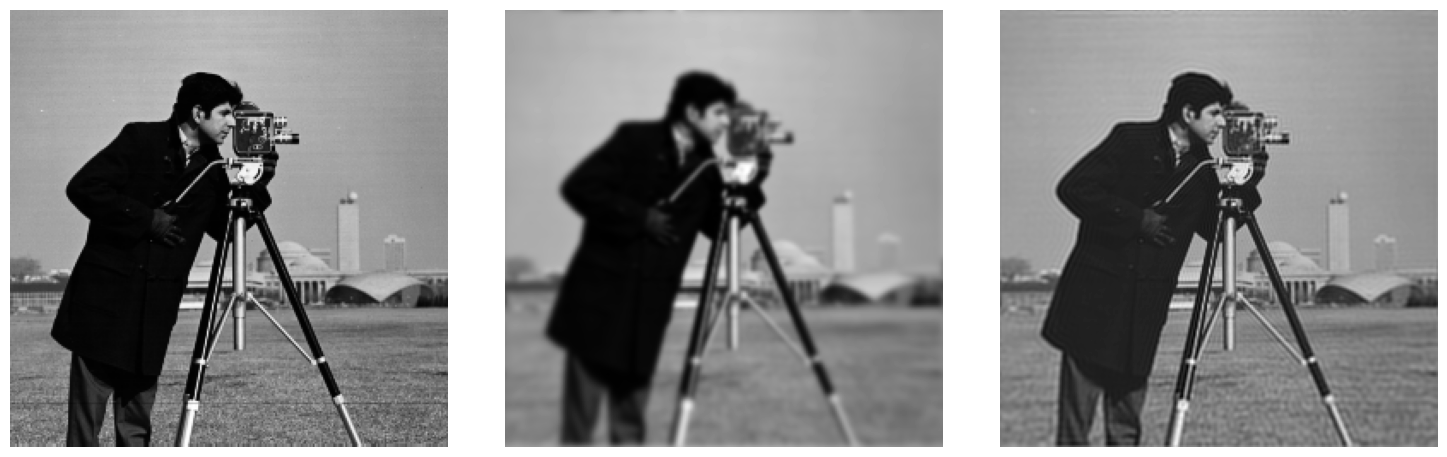

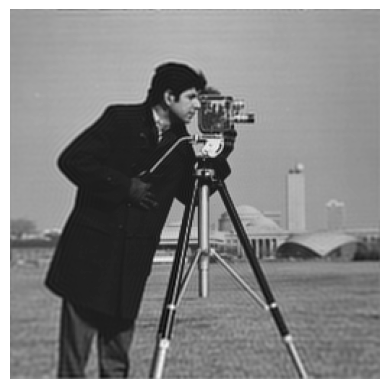

In [34]:
niter=150 # 256*256
tol=5e-7
lamb=1e-8

deblur_pars={'lamb':lamb,'niter':niter,'tol':tol}
deblur_gt=blurtool.l2CGDeblur(blur_gt,deblur_pars)

test_image_hat_gt=deblur_gt(blurred_test_image_gt,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred)=',blurtool.ssim(test_image,test_image_hat_gt))
print('PSNR(original,rpca_deblurred)=',blurtool.psnr(test_image,test_image_hat_gt))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_gt.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()


plt.imshow(test_image_hat_gt.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_gt.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()


sub iteration:  0 	 rj_energy= 29.773734109271544
iter:  0 	 PSNR= 21.536706980781975
sub iteration:  1 	 rj_energy= 4.278941983791929
iter:  1 	 PSNR= 25.37426260753961
sub iteration:  2 	 rj_energy= 1.1951810934811427
iter:  2 	 PSNR= 27.224976776698377
sub iteration:  3 	 rj_energy= 0.4800713715586995
iter:  3 	 PSNR= 28.304307411050562
sub iteration:  4 	 rj_energy= 0.2218714467799085
iter:  4 	 PSNR= 29.051489874696834
sub iteration:  5 	 rj_energy= 0.11984953270554319
iter:  5 	 PSNR= 29.51151983228749
sub iteration:  6 	 rj_energy= 0.07368070428959621
iter:  6 	 PSNR= 29.81842496115137
sub iteration:  7 	 rj_energy= 0.04814625429843898
iter:  7 	 PSNR= 29.628766288468707
sub iteration:  8 	 rj_energy= 0.03289357866196788
iter:  8 	 PSNR= 29.519409580971537
sub iteration:  9 	 rj_energy= 0.02230793294702058
iter:  9 	 PSNR= 29.358681834588324
sub iteration:  10 	 rj_energy= 0.016606358311950654
iter:  10 	 PSNR= 29.12950489497693
sub iteration:  11 	 rj_energy= 0.0127744780352157

sub iteration:  91 	 rj_energy= 2.171701488001168e-05
iter:  91 	 PSNR= 26.27141935102417
sub iteration:  92 	 rj_energy= 2.102599139881947e-05
iter:  92 	 PSNR= 26.209847217157098
sub iteration:  93 	 rj_energy= 2.0489984497971308e-05
iter:  93 	 PSNR= 26.14987878349514
sub iteration:  94 	 rj_energy= 1.9407681564003958e-05
iter:  94 	 PSNR= 26.097154628336234
sub iteration:  95 	 rj_energy= 1.8830343296389106e-05
iter:  95 	 PSNR= 26.04370883663168
sub iteration:  96 	 rj_energy= 1.834855378053685e-05
iter:  96 	 PSNR= 25.98871833712358
sub iteration:  97 	 rj_energy= 1.734636536558631e-05
iter:  97 	 PSNR= 25.93796274418464
sub iteration:  98 	 rj_energy= 1.6824498532036796e-05
iter:  98 	 PSNR= 25.889389703184044
sub iteration:  99 	 rj_energy= 1.706578676817486e-05
iter:  99 	 PSNR= 25.84268800171753
sub iteration:  100 	 rj_energy= 1.6458830644834627e-05
iter:  100 	 PSNR= 25.80030737911155
sub iteration:  101 	 rj_energy= 1.6182994547617067e-05
iter:  101 	 PSNR= 25.755911117502

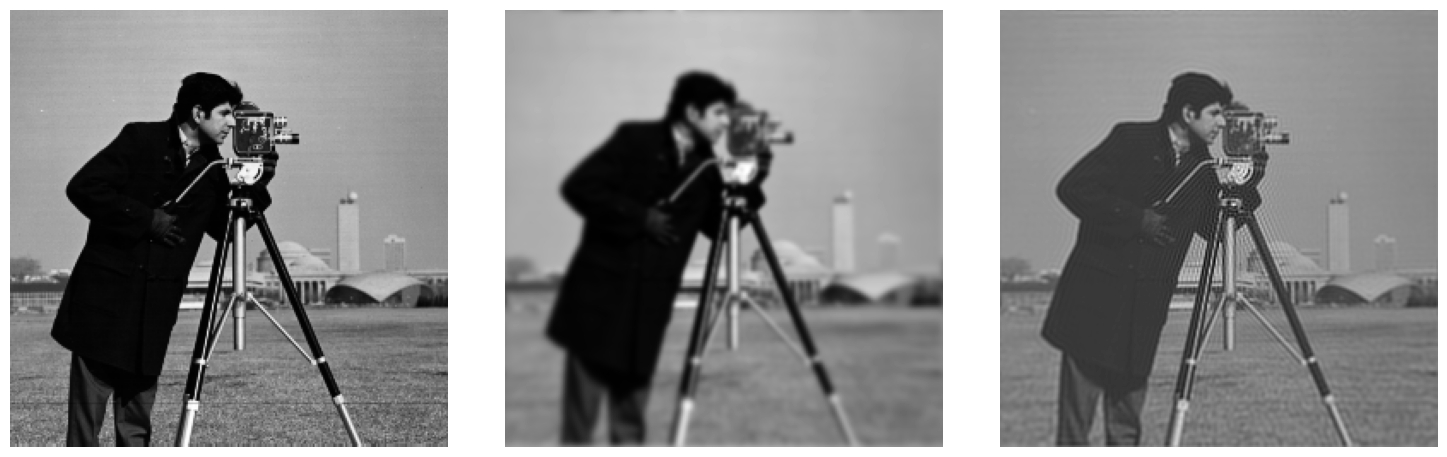

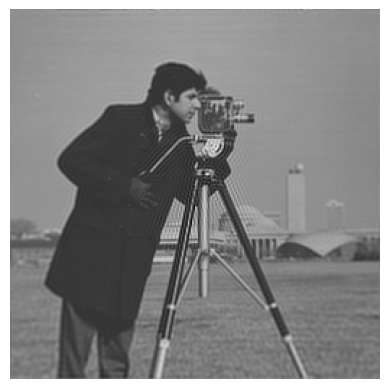

In [35]:
deblur_pars={'lamb':lamb,'niter':niter,'tol':tol}
deblur_rpca=blurtool.l2CGDeblur(rpca_blur,deblur_pars)

test_image_hat_rpca=deblur_rpca(blurred_test_image_gt,x_true=test_image_hat_gt,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred)=',blurtool.ssim(test_image_hat_gt,test_image_hat_rpca))
print('PSNR(original,rpca_deblurred)=',blurtool.psnr(test_image_hat_gt,test_image_hat_rpca))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_rpca.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat_rpca.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_rpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

sub iteration:  0 	 rj_energy= 154.16043941998603
iter:  0 	 PSNR= 14.464500350757245
sub iteration:  1 	 rj_energy= 57.61442842019861
iter:  1 	 PSNR= 18.756140456647557
sub iteration:  2 	 rj_energy= 19.97527357578924
iter:  2 	 PSNR= 17.415658845959353
sub iteration:  3 	 rj_energy= 8.520050778126842
iter:  3 	 PSNR= 16.816068752969432
sub iteration:  4 	 rj_energy= 4.12150957762829
iter:  4 	 PSNR= 16.324727873467403
sub iteration:  5 	 rj_energy= 2.3805694996151923
iter:  5 	 PSNR= 15.862703692467031
sub iteration:  6 	 rj_energy= 1.303639866653664
iter:  6 	 PSNR= 15.495145643478079
sub iteration:  7 	 rj_energy= 0.8828168957562486
iter:  7 	 PSNR= 15.227054609490477
sub iteration:  8 	 rj_energy= 0.5338179341305623
iter:  8 	 PSNR= 14.985600430775516
sub iteration:  9 	 rj_energy= 0.3651003104000946
iter:  9 	 PSNR= 14.83303844412006
sub iteration:  10 	 rj_energy= 0.2552081438509456
iter:  10 	 PSNR= 14.751045843880494
sub iteration:  11 	 rj_energy= 0.17842776728800866
iter:  

sub iteration:  92 	 rj_energy= 0.0003287522551821102
iter:  92 	 PSNR= 14.195704477742492
sub iteration:  93 	 rj_energy= 0.0003270491174977826
iter:  93 	 PSNR= 14.189622051860006
sub iteration:  94 	 rj_energy= 0.0003854523184260338
iter:  94 	 PSNR= 14.18395779104883
sub iteration:  95 	 rj_energy= 0.000347893984571267
iter:  95 	 PSNR= 14.178319453161743
sub iteration:  96 	 rj_energy= 0.00035451631835222645
iter:  96 	 PSNR= 14.1726615650735
sub iteration:  97 	 rj_energy= 0.00032549250530374934
iter:  97 	 PSNR= 14.167050177931834
sub iteration:  98 	 rj_energy= 0.00032028338147538176
iter:  98 	 PSNR= 14.161780809466544
sub iteration:  99 	 rj_energy= 0.00027938055189568407
iter:  99 	 PSNR= 14.15658991676965
sub iteration:  100 	 rj_energy= 0.0002651112834416253
iter:  100 	 PSNR= 14.15100778706572
sub iteration:  101 	 rj_energy= 0.00026295048355700566
iter:  101 	 PSNR= 14.146341449953347
sub iteration:  102 	 rj_energy= 0.00024327383360032656
iter:  102 	 PSNR= 14.140940236

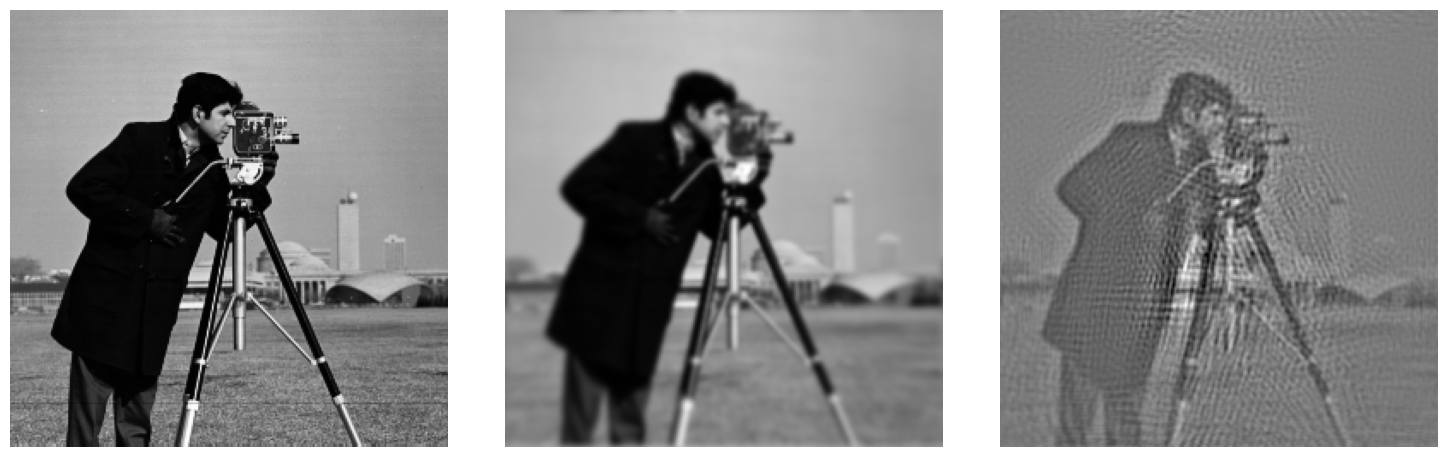

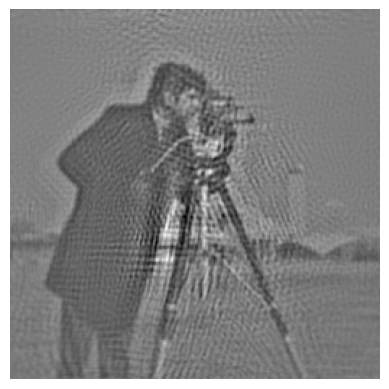

In [36]:
deblur_pars={'lamb':lamb,'niter':niter,'tol':tol}
deblur_pca=blurtool.l2CGDeblur(pca_blur,deblur_pars)

test_image_hat_pca=deblur_pca(blurred_test_image_gt,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,pca_deblurred)=',blurtool.ssim(test_image_hat_gt,test_image_hat_pca))
print('PSNR(original,pca_deblurred)=',blurtool.psnr(test_image_hat_gt,test_image_hat_pca))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_pca.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat_pca.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

### part2 with $16 \times 16$ sampled kernels

In [38]:
# sample original lattice again
sampled_shape16=(16,16)
sampled_lat16=lat.sample(sampled_shape16)

# use individual salt and pepper values
salt_val=None
pepper_val=None

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat16.kernels:
    sampled_lat16.kernels[key].psf_data=blurtool.spnoise(sampled_lat16.kernels[key].psf_data,amount=0.03,salt_val=salt_val,pepper_val=pepper_val) # 0.1 # 0.2
     # amount was 0.1

In [39]:
# decompose sampled lattice
r=64
pars_pca16={'r':r}
pars_rpca16={'lamb':0.16,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # 0.08!!! or .09 for 0.1 of amount

pca_lat16=blurtool.DecomposeLattice(sampled_lat16,img_shape,mode='pca',decompose_pars=pars_pca16)
rpca_lat16=blurtool.DecomposeLattice(sampled_lat16,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca16)


# # plot corrupted sampled kernels
# fig,ax=plt.subplots(sampled_shape16[0],sampled_shape16[1],figsize=(20,15))
# fig.suptitle('corrupted sampled kernels')
# for i in range(sampled_shape16[0]):
#     for j in range(sampled_shape16[1]):
#         ax[i,j].axis('off')
#         ax[i,j].imshow(sampled_lat16.kernel([i,j])().cpu(),cmap='gray')
# plt.show()


# # plot reconsctructed pca noninterpolated kernels
# fig,ax=plt.subplots(sampled_shape16[0],sampled_shape16[1],figsize=(20,15))
# fig.suptitle('recovered rpca noninterpolated kernels 16')
# for i in range(sampled_shape16[0]):
#     for j in range(sampled_shape16[1]):
#         ax[i,j].axis('off')
#         ax[i,j].imshow(pca_lat16.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
# plt.show()

# # plot reconsctructed rpca noninterpolated kernels
# fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
# fig.suptitle('recovered rpca noninterpolated kernels 16')
# for i in range(sampled_shape16[0]):
#     for j in range(sampled_shape16[1]):
#         ax[i,j].axis('off')
#         ax[i,j].imshow(rpca_lat16.noninterpolated_kernel([i,j])().cpu(),cmap='gray')
# plt.show()

mu= tensor(138.6442) . lamb= tensor([0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600, 0.1600,
        0.1

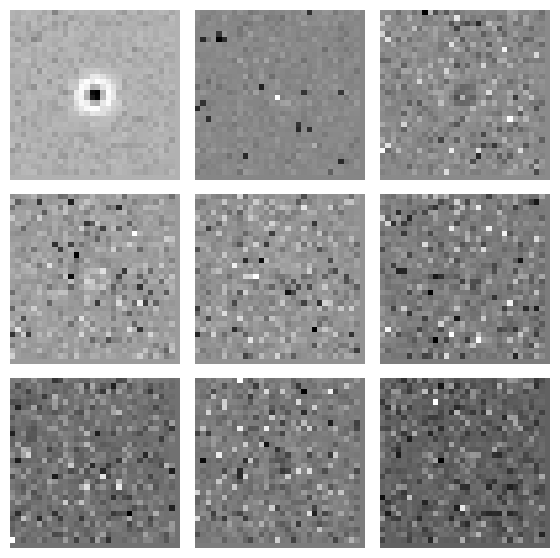

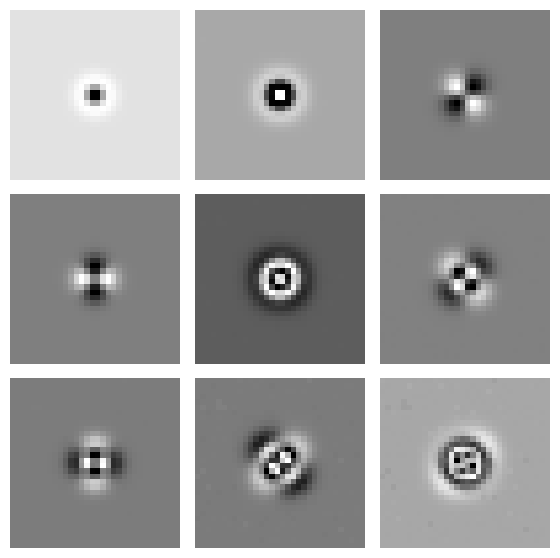

In [40]:
# plot pca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat16.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
# plt.savefig('res0_pca_9eigenkernels16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

# plot rpca kernels
n_rows=3
n_columns=3
fig,ax=plt.subplots(n_rows,n_columns,figsize=(5.7,6))
fig.tight_layout(pad=1, h_pad=0, w_pad=0)
# fig.suptitle('rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat16.eigenkernels[int(1+i*n_rows+j)]().cpu(),cmap='gray')
plt.tight_layout()
# plt.savefig('fig/res0_rpca_9eigenkernels16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

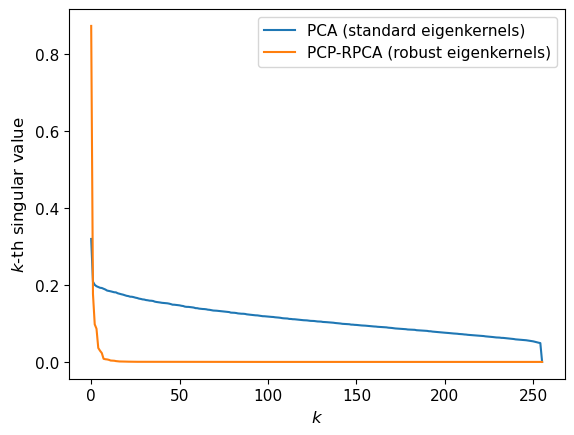

In [41]:
plt.plot(pca_lat16.singularvalues[1:],label='PCA (standard eigenkernels)')
plt.plot(rpca_lat16.singularvalues[1:],label=r'PCP-RPCA (robust eigenkernels)')
plt.ylabel(r'$k$-th singular value',fontsize=12)
plt.xlabel(r'$k$',fontsize=12)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
# plt.savefig('fig/res0_singular_values16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [42]:
# mean PSNR and SSIM

psnr_pca16=[]
psnr_rpca16=[]
ssim_pca16=[]
ssim_rpca16=[]

resampled_lat16=lat.sample(sampled_shape16)

for key in sampled_lat.kernels:
    psnr_pca16.append(blurtool.psnr(resampled_lat16.kernel(key)(),pca_lat16.noninterpolated_kernel(key)()).item())
    psnr_rpca16.append(blurtool.psnr(resampled_lat16.kernel(key)(),rpca_lat16.noninterpolated_kernel(key)()).item())    
    ssim_pca16.append(blurtool.ssim(resampled_lat16.kernel(key)(),pca_lat16.noninterpolated_kernel(key)()).item())
    ssim_rpca16.append(blurtool.ssim(resampled_lat16.kernel(key)(),rpca_lat16.noninterpolated_kernel(key)()).item())

print('-----------------------------')
print('mean PSNR(psf,psf_pca16)=',sum(psnr_pca16)/len(psnr_pca16))
print('mean SSIM(psf,psf_pca16)=',sum(ssim_pca16)/len(ssim_pca16))
print('-----------------------------')
print('mean PSNR(psf,psf_rpca16)=',sum(psnr_rpca16)/len(psnr_rpca16))
print('mean SSIM(psf,psf_rpca16)=',sum(ssim_rpca16)/len(ssim_rpca16))
print('-----------------------------')

/home/mauro/miniconda3/envs/mie/lib/python3.10/site-packages/skimage/_shared/utils.py:348: UserWarning: Inputs have mismatched dtype.  Setting data_range based on im1.dtype.
  return func(*args, **kwargs)


-----------------------------
mean PSNR(psf,psf_pca16)= 16.848278885278845
mean SSIM(psf,psf_pca16)= 0.9908919633062261
-----------------------------
mean PSNR(psf,psf_rpca16)= 88.29259578984475
mean SSIM(psf,psf_rpca16)= 0.9999995673229329
-----------------------------


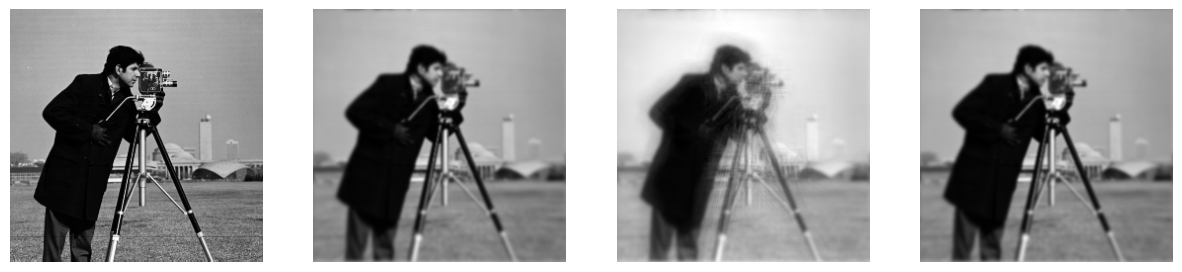

blur.forward_timer= 43.27208920009434
pca_blur.forward_timer= 0.15897144610062242
rpca_blur.forward_timer= 0.1448747431859374
PSNR(blurred,pca_blurred16)= tensor(16.0038, device='cuda:0', dtype=torch.float64)
PSNR(blurred,rpca_blurred16)= tensor(58.1683, device='cuda:0', dtype=torch.float64)
SSIM(blurred,pca_blurred16)= tensor(0.9014, dtype=torch.float64)
SSIM(blurred,rpca_blurred16)= tensor(1.0000, dtype=torch.float64)


In [43]:
## blur a test image 

# define blurs and apply
pca_blur16=blurtool.NonstationaryBlur(pca_lat16)
rpca_blur16=blurtool.NonstationaryBlur(rpca_lat16)

pca_blurred_test_image16=pca_blur16.forward(test_image,debug=False)
rpca_blurred_test_image16=rpca_blur16.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image.cpu(),cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image16.cpu(),cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image16.cpu(),cmap='gray')

plt.show()

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur16.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur16.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred16)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image16))
print('PSNR(blurred,rpca_blurred16)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image16))

print('SSIM(blurred,pca_blurred16)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image16))
print('SSIM(blurred,rpca_blurred16)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image16))


In [44]:
# sample original lattice
resampled_lat_gt16=lat.sample(sampled_shape16)


r=64
pars_gt_pca16={'r':r}
lat_gt16=blurtool.DecomposeLattice(resampled_lat_gt16,img_shape,mode='pca',decompose_pars=pars_gt_pca16)
blur_gt16=blurtool.NonstationaryBlur(lat_gt16)

blurred_test_image_gt16=blur_gt16.forward(test_image)

sub iteration:  0 	 rj_energy= 28.916599724464568
iter:  0 	 PSNR= 21.13766069037014
sub iteration:  1 	 rj_energy= 4.07919897273831
iter:  1 	 PSNR= 22.2297740306241
sub iteration:  2 	 rj_energy= 1.1211448988013617
iter:  2 	 PSNR= 23.145004839214177
sub iteration:  3 	 rj_energy= 0.44727971920060605
iter:  3 	 PSNR= 22.99318113131352
sub iteration:  4 	 rj_energy= 0.20368881483360274
iter:  4 	 PSNR= 22.84221505578269
sub iteration:  5 	 rj_energy= 0.10958211993492466
iter:  5 	 PSNR= 22.85555800036005
sub iteration:  6 	 rj_energy= 0.06773415441220412
iter:  6 	 PSNR= 22.80624584315097
sub iteration:  7 	 rj_energy= 0.04374668274413053
iter:  7 	 PSNR= 22.92049452208172
sub iteration:  8 	 rj_energy= 0.0292030914005374
iter:  8 	 PSNR= 23.047208247843145
sub iteration:  9 	 rj_energy= 0.019495172415780512
iter:  9 	 PSNR= 23.091700422154187
sub iteration:  10 	 rj_energy= 0.01417843089720684
iter:  10 	 PSNR= 23.205673427183786
sub iteration:  11 	 rj_energy= 0.010734853783152214
i

sub iteration:  91 	 rj_energy= 9.194387686168857e-06
iter:  91 	 PSNR= 24.052023469144594
sub iteration:  92 	 rj_energy= 8.913443816667984e-06
iter:  92 	 PSNR= 24.048824249075448
sub iteration:  93 	 rj_energy= 8.833252635698928e-06
iter:  93 	 PSNR= 24.04673407927355
sub iteration:  94 	 rj_energy= 8.333600538570459e-06
iter:  94 	 PSNR= 24.04360709587687
sub iteration:  95 	 rj_energy= 8.063300341292508e-06
iter:  95 	 PSNR= 24.04107146146995
sub iteration:  96 	 rj_energy= 7.730098267033358e-06
iter:  96 	 PSNR= 24.039323669666533
sub iteration:  97 	 rj_energy= 7.433166316644955e-06
iter:  97 	 PSNR= 24.038898025694436
sub iteration:  98 	 rj_energy= 7.2546304629224576e-06
iter:  98 	 PSNR= 24.04129467044429
sub iteration:  99 	 rj_energy= 6.991521930427049e-06
iter:  99 	 PSNR= 24.04662784869982
sub iteration:  100 	 rj_energy= 6.825569210035952e-06
iter:  100 	 PSNR= 24.054401375044414
sub iteration:  101 	 rj_energy= 6.6544566724392755e-06
iter:  101 	 PSNR= 24.06310937588666

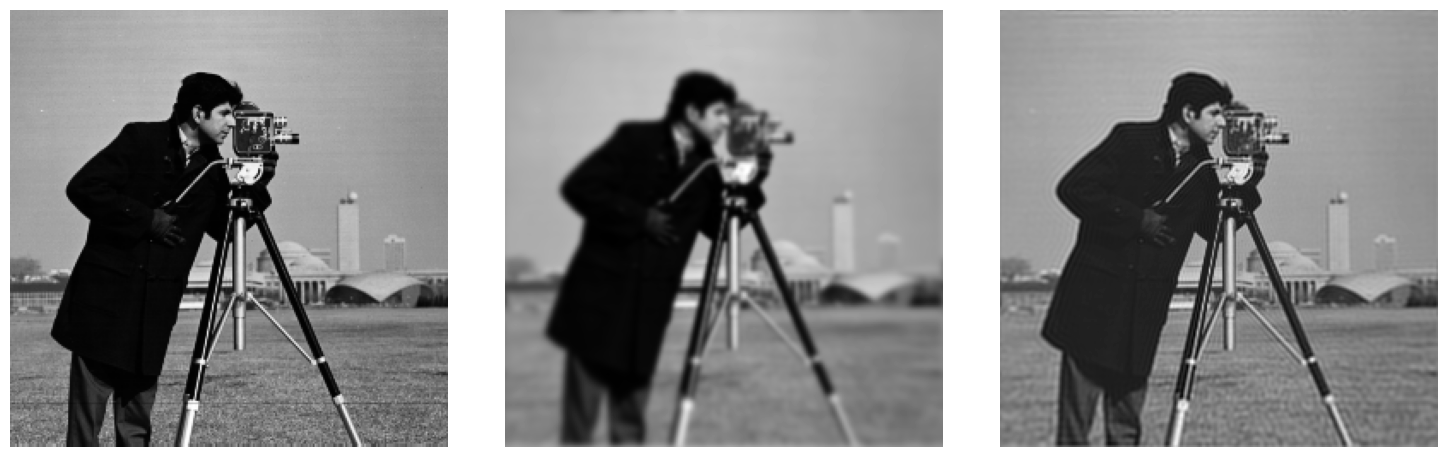

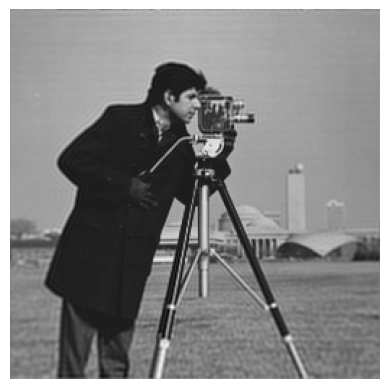

In [45]:
niter=150 # 256*256
tol=1e-7
lamb=1e-8

deblur_pars16={'lamb':lamb,'niter':niter,'tol':tol}
deblur_gt16=blurtool.l2CGDeblur(blur_gt16,deblur_pars16)

test_image_hat_gt16=deblur_gt16(blurred_test_image_gt16,x_true=test_image,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred16)=',blurtool.ssim(test_image,test_image_hat_gt16))
print('PSNR(original,rpca_deblurred16)=',blurtool.psnr(test_image,test_image_hat_gt16))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt16.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_gt16.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()


plt.imshow(test_image_hat_gt16.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_gt16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()


sub iteration:  0 	 rj_energy= 29.05537544406569
iter:  0 	 PSNR= 21.624708514911433
sub iteration:  1 	 rj_energy= 4.108882705459468
iter:  1 	 PSNR= 25.34594842237352
sub iteration:  2 	 rj_energy= 1.1313225982384933
iter:  2 	 PSNR= 27.16715860647686
sub iteration:  3 	 rj_energy= 0.45074389361416134
iter:  3 	 PSNR= 28.448009363380613
sub iteration:  4 	 rj_energy= 0.2056039060242879
iter:  4 	 PSNR= 29.27479394029026
sub iteration:  5 	 rj_energy= 0.11069457423613824
iter:  5 	 PSNR= 29.791686807446325
sub iteration:  6 	 rj_energy= 0.06809826644277446
iter:  6 	 PSNR= 30.185665743723273
sub iteration:  7 	 rj_energy= 0.04439723354736869
iter:  7 	 PSNR= 30.546593094949298
sub iteration:  8 	 rj_energy= 0.029707301847357315
iter:  8 	 PSNR= 30.916463690972286
sub iteration:  9 	 rj_energy= 0.019822803423640848
iter:  9 	 PSNR= 31.19825184912667
sub iteration:  10 	 rj_energy= 0.014422951401117556
iter:  10 	 PSNR= 31.524992831327495
sub iteration:  11 	 rj_energy= 0.01089248009459

sub iteration:  92 	 rj_energy= 9.342259554463639e-06
iter:  92 	 PSNR= 44.051841988907285
sub iteration:  93 	 rj_energy= 9.383827256444487e-06
iter:  93 	 PSNR= 44.19503020893331
sub iteration:  94 	 rj_energy= 8.96892391549091e-06
iter:  94 	 PSNR= 44.337221433043155
sub iteration:  95 	 rj_energy= 8.564771027042966e-06
iter:  95 	 PSNR= 44.47627035635583
sub iteration:  96 	 rj_energy= 8.24700384155508e-06
iter:  96 	 PSNR= 44.62238797239981
sub iteration:  97 	 rj_energy= 7.85393274233214e-06
iter:  97 	 PSNR= 44.76457620021918
sub iteration:  98 	 rj_energy= 7.744330626357698e-06
iter:  98 	 PSNR= 44.906876727986486
sub iteration:  99 	 rj_energy= 7.356578111557297e-06
iter:  99 	 PSNR= 45.058376001151885
sub iteration:  100 	 rj_energy= 7.1312906698923185e-06
iter:  100 	 PSNR= 45.2205701272165
sub iteration:  101 	 rj_energy= 7.101246061882098e-06
iter:  101 	 PSNR= 45.38260687941389
sub iteration:  102 	 rj_energy= 6.8897843721124565e-06
iter:  102 	 PSNR= 45.546101200401694
s

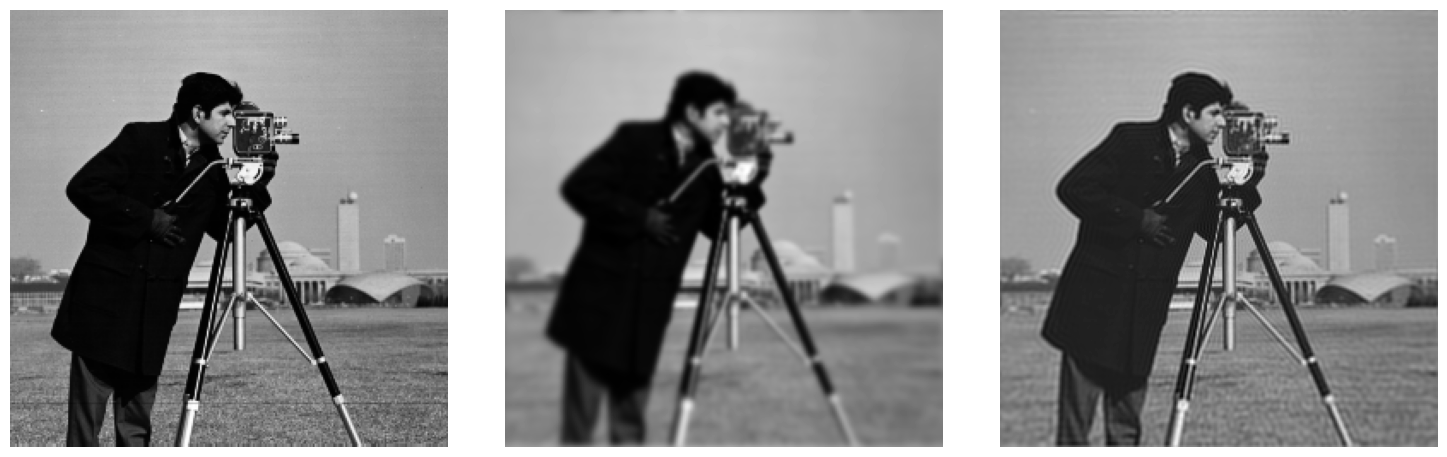

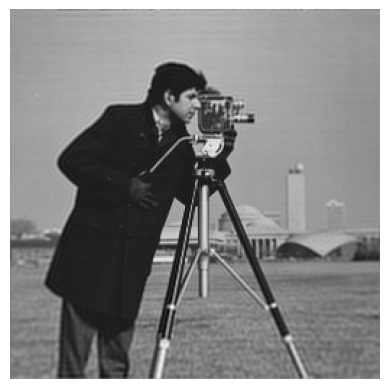

In [46]:
deblur_pars16={'lamb':lamb,'niter':niter,'tol':tol}
deblur_rpca16=blurtool.l2CGDeblur(rpca_blur16,deblur_pars16)

test_image_hat_rpca16=deblur_rpca16(blurred_test_image_gt16,x_true=test_image_hat_gt16,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,rpca_deblurred16)=',blurtool.ssim(test_image_hat_gt16,test_image_hat_rpca16))
print('PSNR(original,rpca_deblurred16)=',blurtool.psnr(test_image_hat_gt16,test_image_hat_rpca16))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt16.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_rpca16.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat_rpca16.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_rpca16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

sub iteration:  0 	 rj_energy= 133.41864092224813
iter:  0 	 PSNR= 14.877890300797915
sub iteration:  1 	 rj_energy= 54.45985540947288
iter:  1 	 PSNR= 18.64679080420509
sub iteration:  2 	 rj_energy= 21.449241758515548
iter:  2 	 PSNR= 21.274055114067224
sub iteration:  3 	 rj_energy= 9.11385057772649
iter:  3 	 PSNR= 20.072571178334293
sub iteration:  4 	 rj_energy= 4.570772739016772
iter:  4 	 PSNR= 18.964093911447645
sub iteration:  5 	 rj_energy= 2.5855066278431966
iter:  5 	 PSNR= 18.34581718837194
sub iteration:  6 	 rj_energy= 1.3898777684349057
iter:  6 	 PSNR= 17.948391072591495
sub iteration:  7 	 rj_energy= 0.8258668952998944
iter:  7 	 PSNR= 17.719844108944805
sub iteration:  8 	 rj_energy= 0.5004415796410935
iter:  8 	 PSNR= 17.51315639638684
sub iteration:  9 	 rj_energy= 0.3461536942268183
iter:  9 	 PSNR= 17.29622716717077
sub iteration:  10 	 rj_energy= 0.2509813530423185
iter:  10 	 PSNR= 17.15115736343591
sub iteration:  11 	 rj_energy= 0.18127738859090986
iter:  11

sub iteration:  92 	 rj_energy= 0.00024914760755619266
iter:  92 	 PSNR= 16.048320217568037
sub iteration:  93 	 rj_energy= 0.00022328185735794005
iter:  93 	 PSNR= 16.049574820061768
sub iteration:  94 	 rj_energy= 0.00019558237755437174
iter:  94 	 PSNR= 16.050209010572583
sub iteration:  95 	 rj_energy= 0.00019643675365982698
iter:  95 	 PSNR= 16.04997455281776
sub iteration:  96 	 rj_energy= 0.00019329380135646294
iter:  96 	 PSNR= 16.05005435066588
sub iteration:  97 	 rj_energy= 0.00019282697832786748
iter:  97 	 PSNR= 16.05003202679394
sub iteration:  98 	 rj_energy= 0.00017700944164530293
iter:  98 	 PSNR= 16.05008644214055
sub iteration:  99 	 rj_energy= 0.00017380614267597665
iter:  99 	 PSNR= 16.050060676549066
sub iteration:  100 	 rj_energy= 0.00019165606925720951
iter:  100 	 PSNR= 16.050666658466188
sub iteration:  101 	 rj_energy= 0.0001736768639582019
iter:  101 	 PSNR= 16.05201125236706
sub iteration:  102 	 rj_energy= 0.00017211981053421563
iter:  102 	 PSNR= 16.0534

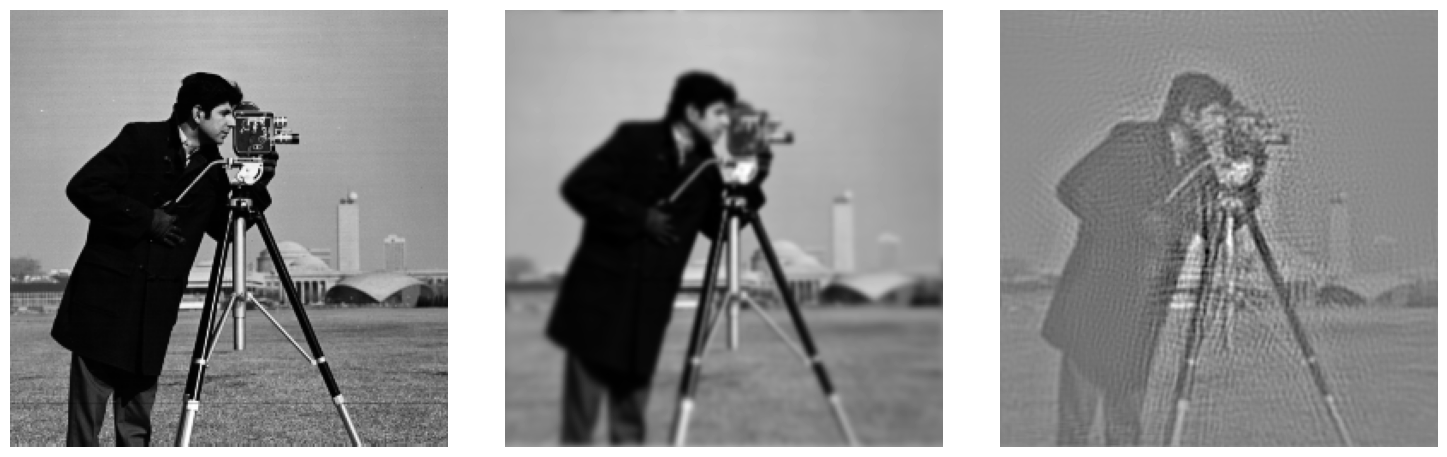

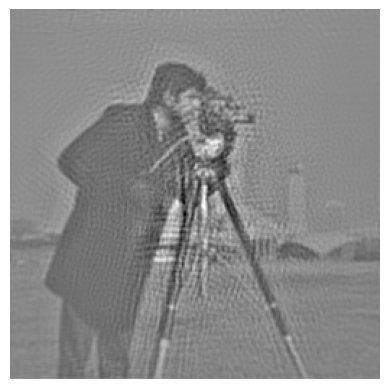

In [47]:
deblur_pars16={'lamb':lamb,'niter':niter,'tol':tol}
deblur_pca16=blurtool.l2CGDeblur(pca_blur16,deblur_pars16)

test_image_hat_pca16=deblur_pca16(blurred_test_image_gt16,x_true=test_image_hat_gt16,debug=True)

fig,ax=plt.subplots(1,3,figsize=(15,15))
plt.tight_layout()

print('-------------------------------------------')
print('SSIM(original,pca_deblurred16)=',blurtool.ssim(test_image_hat_gt16,test_image_hat_pca16))
print('PSNR(original,pca_deblurred16)=',blurtool.psnr(test_image_hat_gt16,test_image_hat_pca16))
print('-------------------------------------------')

ax[0].axis('off')
ax[0].imshow(test_image.cpu(),cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_gt16.cpu(),cmap='gray')
ax[1].axis('off')
ax[2].imshow(test_image_hat_pca16.cpu(),cmap='gray')
ax[2].axis('off')
plt.show()

plt.imshow(test_image_hat_pca16.cpu(),cmap='gray')
plt.axis('off')
plt.savefig('fig/res1_x_pca16.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()